In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats

In [2]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [5]:
h = 0.6774

In [6]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/tmp/ipykernel_2163008/565162213.py:1: RuntimeWarning: divide by zero encountered in log10
  mvir = np.log10(halos["Group_M_TopHat200"]*1e10)


In [7]:
group_sfr = np.log10(halos["GroupSFR"])

/tmp/ipykernel_2163008/1790017200.py:1: RuntimeWarning: divide by zero encountered in log10
  group_sfr = np.log10(halos["GroupSFR"])


In [8]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10


<class 'dict'>


In [9]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [10]:
mask0 = halos["GroupFirstSub"]==-1

In [11]:
subhalos["SubhaloSFR"][-1] # If halos["GroupFirstSub"]==-1 then cent SFR will be 0

0.0

In [12]:
cent_sfrs1 = subhalos["SubhaloSFR"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]

In [13]:
cent_sfrs = np.zeros(len(mvir))
cent_sfrs[halos["GroupFirstSub"]>-1] = cent_sfrs1
cent_sfrs = np.log10(cent_sfrs)

/tmp/ipykernel_2163008/2662205001.py:3: RuntimeWarning: divide by zero encountered in log10
  cent_sfrs = np.log10(cent_sfrs)


In [14]:
cent_mass1 = subhalos["SubhaloMass"][cent_mask_all]*1e10

In [15]:
cent_mass = np.zeros(len(mvir))
cent_mass[halos["GroupFirstSub"]>-1] = cent_mass1
cent_mass = np.log10(cent_mass)

/tmp/ipykernel_2163008/640957417.py:3: RuntimeWarning: divide by zero encountered in log10
  cent_mass = np.log10(cent_mass)


In [16]:
Mbh_sub = np.log10(subhalos["SubhaloBHMass"]*1e10)

/tmp/ipykernel_2163008/775281979.py:1: RuntimeWarning: divide by zero encountered in log10
  Mbh_sub = np.log10(subhalos["SubhaloBHMass"]*1e10)


In [17]:
Mbh_cent =  np.zeros(len(mvir))
Mbh_cent[halos["GroupFirstSub"]>-1] = Mbh_sub[cent_mask_all]

In [18]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [19]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [20]:
mask_nonzero_sat = (sat_mass > 0) & (sat_sfrs > 0)

In [21]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [22]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [23]:
sum_sfrs = np.zeros(len(group_sfr))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/tmp/ipykernel_2163008/2738257778.py:3: RuntimeWarning: divide by zero encountered in log10
  sum_sfrs = np.log10(sum_sfrs)


In [24]:
sum_mass1 =  np.add.reduceat(sat_mass, indices)

In [25]:

sum_sat_mass = np.zeros(len(group_sfr))
sum_sat_mass[unique_ids] = sum_mass1
sum_sat_mass = np.log10(sum_sat_mass)

/tmp/ipykernel_2163008/4205110434.py:3: RuntimeWarning: divide by zero encountered in log10
  sum_sat_mass = np.log10(sum_sat_mass)


SignificanceResult(statistic=-0.04232736962021476, pvalue=6.023612791335736e-08)


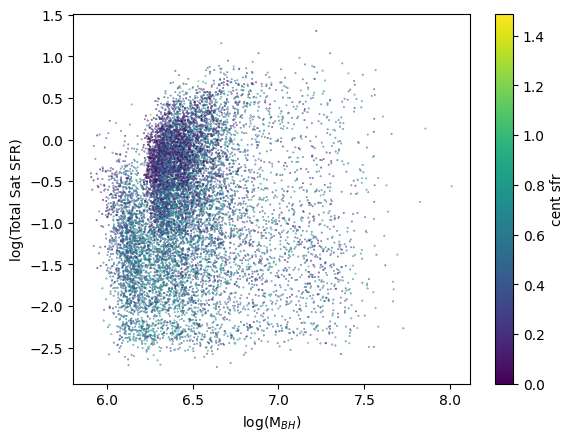

In [37]:
mask = (mvir > 11.5) & (mvir < 11.6)
plt.scatter(np.log10(halos["GroupBHMass"][mask]*1e10), sum_sfrs[mask], s=0.1, c=cent_sfrs[mask],vmin=0)
plt.ylabel("log(Total Sat SFR)")
plt.xlabel("log(M$_{BH}$)")
coef1 = stats.spearmanr(sum_sfrs[mask],halos["GroupBHMass"][mask])
print(coef1)
#plt.ylabel("log(M$_{BH}$)")
plt.colorbar(label="cent sfr")

SignificanceResult(statistic=-0.032598086292687886, pvalue=3.020114529337706e-05)


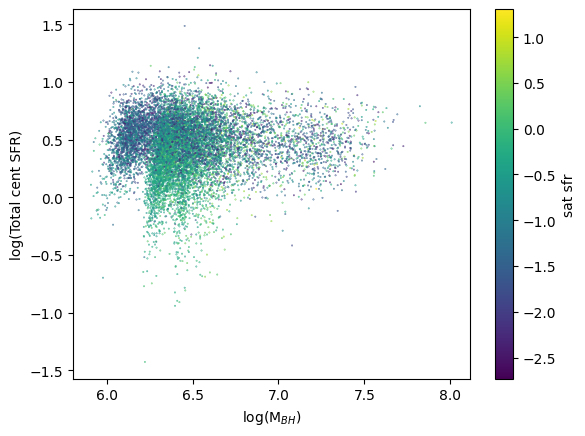

In [33]:
mask = (mvir > 11.5) & (mvir < 11.6)
plt.scatter(np.log10(halos["GroupBHMass"][mask]*1e10), cent_sfrs[mask], s=0.1, c=sum_sfrs[mask])
plt.ylabel("log(Total cent SFR)")
plt.xlabel("log(M$_{BH}$)")
coef1 = stats.spearmanr(cent_sfrs[mask],halos["GroupBHMass"][mask])
print(coef1)
#plt.ylabel("log(M$_{BH}$)")
plt.colorbar(label="sat sfr")

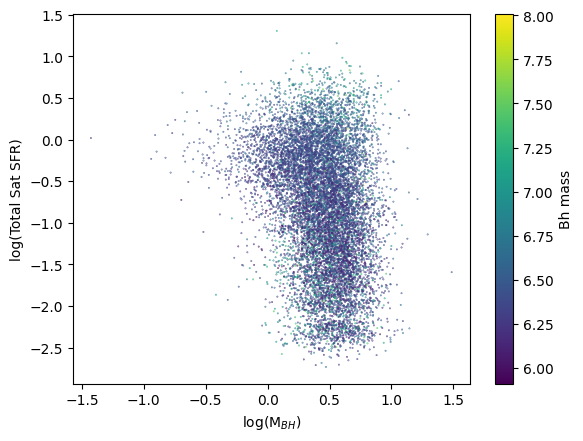

In [39]:
mask = (mvir > 11.5) & (mvir < 11.6)
plt.scatter(cent_sfrs[mask], sum_sfrs[mask], s=0.1, c=np.log10(halos["GroupBHMass"][mask]*1e10))
plt.ylabel("log(Total Sat SFR)")
plt.xlabel("log(M$_{BH}$)")
# coef1 = stats.spearmanr(sum_sfrs[mask],halos["GroupBHMass"][mask])
# print(coef1)
#plt.ylabel("log(M$_{BH}$)")
plt.colorbar(label="Bh mass")